# E2R (Easy-to-Read) Analysis - Part 2 Consolidated Data

This notebook provides a comprehensive analysis of student evaluations of web pages using E2R guidelines and various AI tools.

## Research Questions
1. How much time does a user spend to evaluate a webpage?
2. Which webpage takes the longest time?
3. Which elements can LLMs identify easily?
4. Which tool is most accurate?
5. What are the most common E2R violations?
6. Are there differences between student groups?

## Section 0: Setup & Imports

In [315]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from collections import Counter
from urllib.parse import urlparse
import warnings

# Configuration
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.width', 1000)

plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 10
sns.set_style('whitegrid')
sns.set_palette('husl')

warnings.filterwarnings('ignore')

print("Setup complete!")

Setup complete!


## Section 1: Data Loading & Initial Exploration

In [316]:
# Load the cleaned CSV file
df_clean = pd.read_csv('part2_cleaned.csv', encoding='utf-8-sig')
df = df_clean  # Alias for backward compatibility in the notebook

print(f"Dataset shape: {df_clean.shape[0]} rows × {df_clean.shape[1]} columns")
print(f"\nColumn names:")
print(df_clean.columns.tolist())


Dataset shape: 1716 rows × 11 columns

Column names:
['E2R Guidelines', 'Elements to be identified', 'Value', 'Details', 'Comments', 'Tool used', 'Comment', 'Time Spent', 'Group', 'Web', 'E2R_Category']


In [317]:
# Display dataset information
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1716 entries, 0 to 1715
Data columns (total 11 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   E2R Guidelines             1716 non-null   str    
 1   Elements to be identified  1716 non-null   str    
 2   Value                      1716 non-null   str    
 3   Details                    1437 non-null   str    
 4   Comments                   1259 non-null   str    
 5   Tool used                  1716 non-null   str    
 6   Comment                    762 non-null    str    
 7   Time Spent                 1716 non-null   float64
 8   Group                      1716 non-null   int64  
 9   Web                        1627 non-null   str    
 10  E2R_Category               1716 non-null   str    
dtypes: float64(1), int64(1), str(9)
memory usage: 147.6 KB


In [318]:
# Show first few rows
df.head(3)

,E2R Guidelines,Elements to be identified,Value,Details,Comments,Tool used,Comment,Time Spent,Group,Web,E2R_Category
0,E2R Guidelines about Spelling,"Special characters like \, &, <, § or #",Identified by the evaluator (in a manual way),Not used.,The tool found some but there was no,Copilot,"CoPilot is a decent tool to use for this, but ...",25.0,1,https://theconversation.com/google-is-relying-...,Spelling
1,E2R Guidelines about Spelling,Parenthesis and square brackets,Identified by the tool,Used.,The tool was able to identify this correct,Copilot,"CoPilot is a decent tool to use for this, but ...",25.0,1,https://theconversation.com/google-is-relying-...,Spelling
2,E2R Guidelines about Spelling,"Abbreviations, acronyms, and initials",Identified by the tool,"yes. E.g. GPU, TPU, AI, LLM without always def...",The tool was able to identify this correct,Copilot,"CoPilot is a decent tool to use for this, but ...",25.0,1,https://theconversation.com/google-is-relying-...,Spelling


In [319]:
# Show last few rows
df.tail(3)

,E2R Guidelines,Elements to be identified,Value,Details,Comments,Tool used,Comment,Time Spent,Group,Web,E2R_Category
1713,E2R Guidelines about Vocabulary,Superlatives,Identified by the tool,"Examples: “best legacy”, “biggest problems”.",NaN,Gemini,NaN,30.0,30,https://theconversation.com/celebrities-are-cl...,Vocabulary
1714,E2R Guidelines about Composition of Text,List things using commas instead of bullet points,Identified by the tool,"Examples: “time, emotion, energy and lots of m...",NaN,ChatGPT,NaN,30.0,30,https://theconversation.com/celebrities-are-cl...,Composition
1715,E2R Guidelines about Composition of Text,List things using commas instead of bullet points,Identified by the tool,"Examples: “time, emotion, energy and lots of m...",NaN,Gemini,NaN,30.0,30,https://theconversation.com/celebrities-are-cl...,Composition


In [320]:
# Null value analysis
null_counts = df.isnull().sum()
null_percentages = (df.isnull().sum() / len(df)) * 100

null_summary = pd.DataFrame({
    'Null Count': null_counts,
    'Null Percentage': null_percentages.round(2)
}).sort_values('Null Count', ascending=False)

print("Missing Values Summary:")
print(null_summary[null_summary['Null Count'] > 0])

Missing Values Summary:
          Null Count  Null Percentage
Comment          954            55.59
Comments         457            26.63
Details          279            16.26
Web               89             5.19


In [321]:
# Unique values in key columns
print(f"Unique E2R Guidelines: {df['E2R Guidelines'].nunique()}")
print(f"Unique Elements to be identified: {df['Elements to be identified'].nunique()}")
print(f"Unique Tools: {df['Tool used'].nunique()}")
print(f"Unique Groups: {df['Group'].nunique()}")
print(f"Unique Websites: {df['Web'].nunique()}")
print(f"\nValue categories:")
print(df['Value'].value_counts())

Unique E2R Guidelines: 5
Unique Elements to be identified: 18
Unique Tools: 4
Unique Groups: 29
Unique Websites: 22

Value categories:
Value
Identified by the tool                           1167
Not identified by the tool                        302
Partially identified by the tool                  157
Identified by the evaluator (in a manual way)      84
Unknown                                             6
Name: count, dtype: int64


## Section 2: Data Cleaning & Normalization

We'll normalize the data to ensure consistency across submissions.

In [322]:
# Display cleaned data sample
print("Cleaned data sample:")
df_clean.head(3)

Cleaned data sample:


,E2R Guidelines,Elements to be identified,Value,Details,Comments,Tool used,Comment,Time Spent,Group,Web,E2R_Category
0,E2R Guidelines about Spelling,"Special characters like \, &, <, § or #",Identified by the evaluator (in a manual way),Not used.,The tool found some but there was no,Copilot,"CoPilot is a decent tool to use for this, but ...",25.0,1,https://theconversation.com/google-is-relying-...,Spelling
1,E2R Guidelines about Spelling,Parenthesis and square brackets,Identified by the tool,Used.,The tool was able to identify this correct,Copilot,"CoPilot is a decent tool to use for this, but ...",25.0,1,https://theconversation.com/google-is-relying-...,Spelling
2,E2R Guidelines about Spelling,"Abbreviations, acronyms, and initials",Identified by the tool,"yes. E.g. GPU, TPU, AI, LLM without always def...",The tool was able to identify this correct,Copilot,"CoPilot is a decent tool to use for this, but ...",25.0,1,https://theconversation.com/google-is-relying-...,Spelling


In [323]:
# Summary statistics after cleaning
print("Tools after normalization:")
print(df_clean['Tool used'].value_counts())
print(f"\nE2R Categories:")
print(df_clean['E2R_Category'].value_counts())

Tools after normalization:
Tool used
ChatGPT    835
Gemini     731
Claude      90
Copilot     60
Name: count, dtype: int64

E2R Categories:
E2R_Category
Spelling       688
Grammar        460
Vocabulary     460
Composition    108
Name: count, dtype: int64


## Section 3: Time Analysis

### Research Question 1: How much time does a user spend to evaluate a webpage?
### Research Question 2: Which webpage takes the longest time?

In [324]:
# Overall time statistics (excluding zeros)
time_nonzero = df_clean[df_clean['Time Spent'] > 0]['Time Spent']

print("Overall Time Statistics (minutes):")
print(time_nonzero.describe())
print(f"\nTotal entries with time data: {len(time_nonzero)}")
print(f"Entries with zero/missing time: {len(df_clean) - len(time_nonzero)}")

Overall Time Statistics (minutes):
count    1507.000000
mean       46.841407
std        29.079676
min        10.000000
25%        30.000000
50%        45.000000
75%        60.000000
max       210.000000
Name: Time Spent, dtype: float64

Total entries with time data: 1507
Entries with zero/missing time: 209


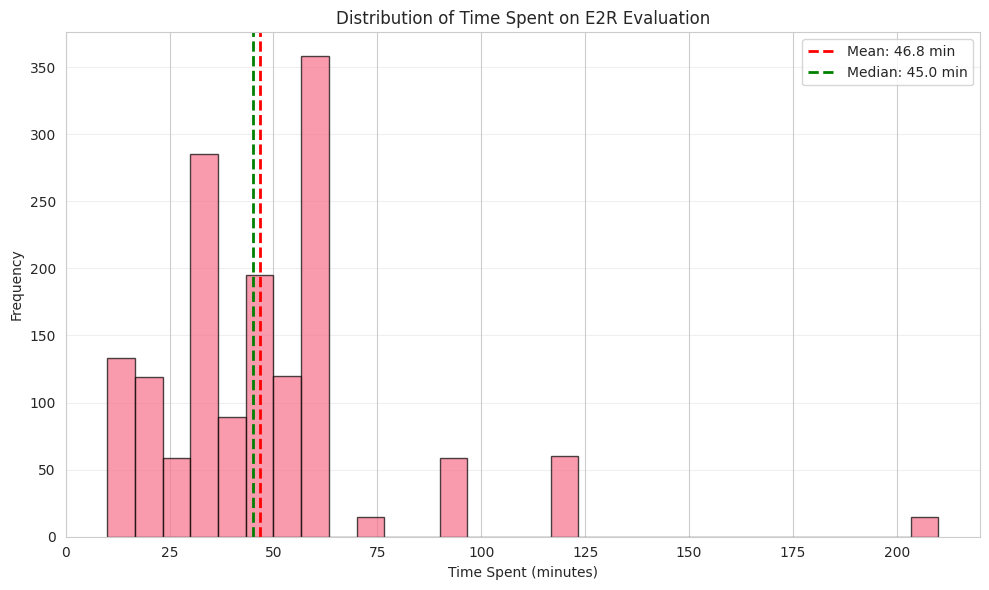

In [325]:
# Visualization: Time distribution histogram
plt.figure(figsize=(10, 6))
plt.hist(time_nonzero, bins=30, edgecolor='black', alpha=0.7)
plt.axvline(time_nonzero.mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {time_nonzero.mean():.1f} min')
plt.axvline(time_nonzero.median(), color='green', linestyle='--', linewidth=2, label=f'Median: {time_nonzero.median():.1f} min')
plt.xlabel('Time Spent (minutes)')
plt.ylabel('Frequency')
plt.title('Distribution of Time Spent on E2R Evaluation')
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

### 3.2 Time by Tool

In [326]:
# Time statistics by tool
time_by_tool = df_clean.groupby('Tool used')['Time Spent'].describe()
print("Time Statistics by Tool (minutes):")
print(time_by_tool.round(2))

Time Statistics by Tool (minutes):
           count   mean    std   min   25%   50%   75%    max
Tool used                                                    
ChatGPT    835.0  42.59  35.40   0.0  30.0  40.0  55.0  210.0
Claude      90.0  55.00   7.68  40.0  50.0  60.0  60.0   60.0
Copilot     60.0  27.50   2.52  25.0  25.0  27.5  30.0   30.0
Gemini     731.0  38.89  28.46   0.0  11.0  45.0  60.0  120.0


In [327]:
# Statistical test: ANOVA for time differences across tools
# Get main tools (excluding website-specific entries)
main_tools = ['ChatGPT', 'Gemini', 'Copilot', 'Claude']
tool_groups = [df_clean[df_clean['Tool used'] == tool]['Time Spent'].values 
               for tool in main_tools if len(df_clean[df_clean['Tool used'] == tool]) > 0]

f_stat, p_value = stats.f_oneway(*tool_groups)
print(f"ANOVA Test for Time Differences Across Tools:")
print(f"F-statistic: {f_stat:.4f}")
print(f"p-value: {p_value:.4f}")
print(f"\nConclusion: {'Significant difference' if p_value < 0.05 else 'No significant difference'} in time spent across tools (α=0.05)")

ANOVA Test for Time Differences Across Tools:
F-statistic: 11.7904
p-value: 0.0000

Conclusion: Significant difference in time spent across tools (α=0.05)


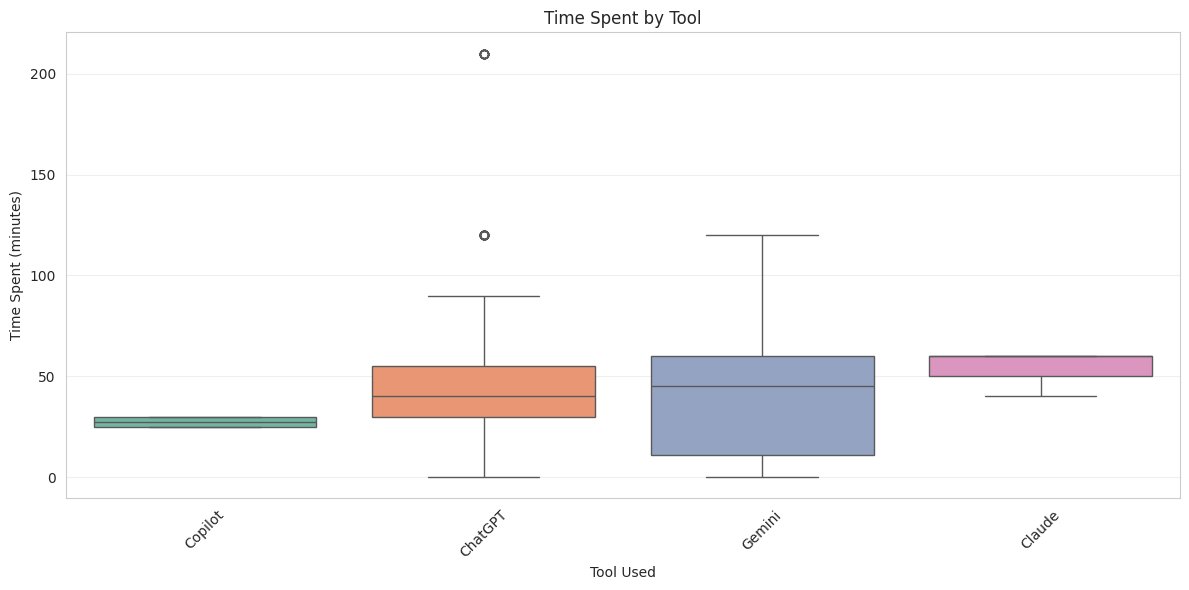

In [328]:
# Visualization: Box plot of time by tool
plt.figure(figsize=(12, 6))
df_tool_filtered = df_clean[df_clean['Tool used'].isin(main_tools)]
sns.boxplot(data=df_tool_filtered, x='Tool used', y='Time Spent', palette='Set2')
plt.xlabel('Tool Used')
plt.ylabel('Time Spent (minutes)')
plt.title('Time Spent by Tool')
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

### 3.3 Time by E2R Category

In [329]:
# Average time by E2R category
time_by_category = df_clean.groupby('E2R_Category')['Time Spent'].agg(['mean', 'median', 'count']).round(2)
time_by_category = time_by_category.sort_values('mean', ascending=False)
print("Time Statistics by E2R Category:")
print(time_by_category)

Time Statistics by E2R Category:
               mean  median  count
E2R_Category                      
Spelling      41.19    40.0    688
Grammar       41.10    40.0    460
Vocabulary    41.10    40.0    460
Composition   41.04    40.0    108


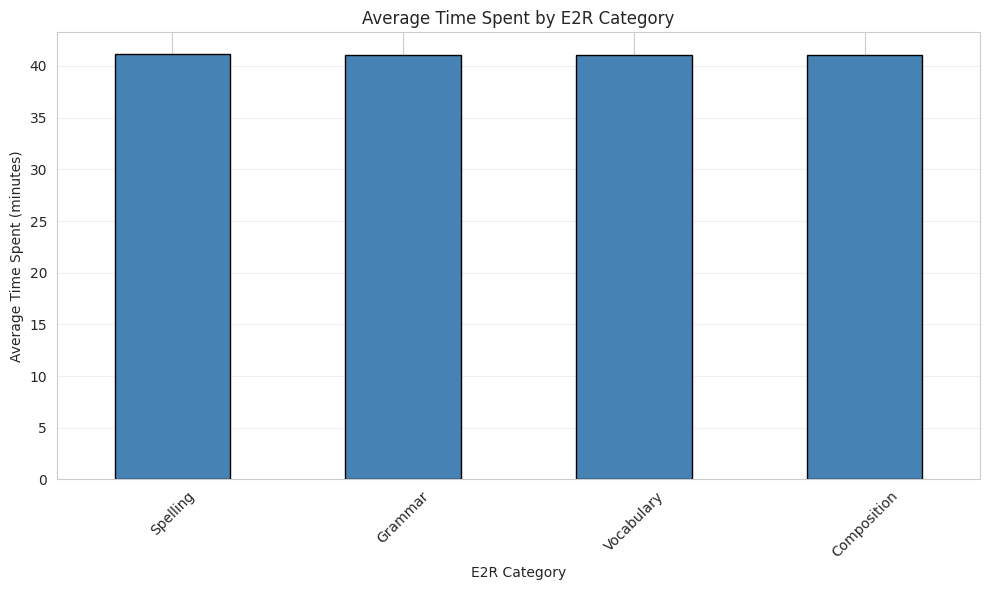

In [330]:
# Visualization: Bar chart of average time by category
plt.figure(figsize=(10, 6))
time_by_category['mean'].plot(kind='bar', color='steelblue', edgecolor='black')
plt.xlabel('E2R Category')
plt.ylabel('Average Time Spent (minutes)')
plt.title('Average Time Spent by E2R Category')
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

### 3.4 Time by Student Group

In [331]:
# Time statistics by group
time_by_group = df_clean.groupby('Group')['Time Spent'].agg(['mean', 'median', 'count']).round(2)
time_by_group = time_by_group.sort_values('mean', ascending=False)
print("Top 10 Groups by Average Time Spent:")
print(time_by_group.head(10))
print("\nBottom 10 Groups by Average Time Spent:")
print(time_by_group.tail(10))

Top 10 Groups by Average Time Spent:
        mean  median  count
Group                      
9      90.00    90.0     44
20     80.45   120.0     88
15     76.67    65.0     90
5      70.00     0.0     45
8      60.00    60.0     15
17     60.00    60.0     15
6      58.33    60.0     45
16     52.50    60.0     60
28     52.50    60.0     60
13     52.50    52.5     90

Bottom 10 Groups by Average Time Spent:
        mean  median  count
Group                      
30     30.00    30.0     90
21     30.00    30.0     90
23     26.67    30.0     45
29     21.67    20.0     45
2      20.00    20.0     15
12     20.00    20.0     14
7      14.50    14.0     90
14     10.00    10.0     43
22      6.74    10.0     89
3       0.00     0.0     90


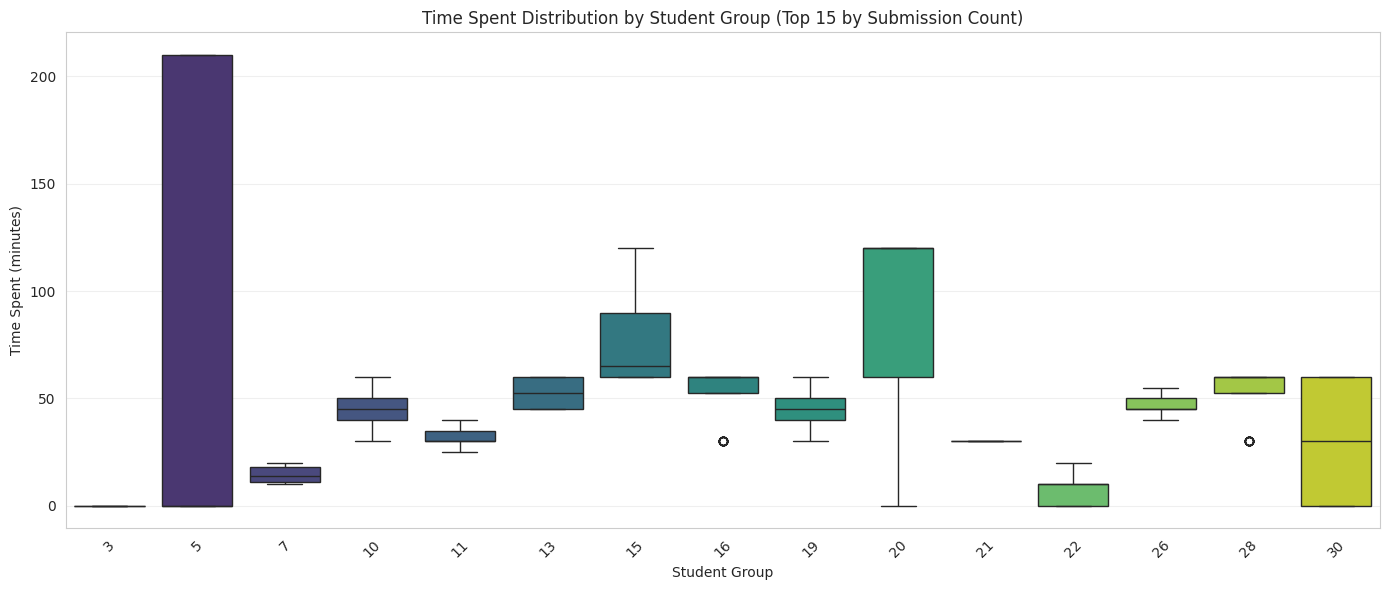

In [332]:
# Visualization: Box plot for top 15 groups by submission count
top_groups = time_by_group.nlargest(15, 'count').index.tolist()
df_top_groups = df_clean[df_clean['Group'].isin(top_groups)]

plt.figure(figsize=(14, 6))
sns.boxplot(data=df_top_groups, x='Group', y='Time Spent', palette='viridis')
plt.xlabel('Student Group')
plt.ylabel('Time Spent (minutes)')
plt.title('Time Spent Distribution by Student Group (Top 15 by Submission Count)')
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

### 3.5 Time by Website

In [333]:
# Average time by website (top 15)
time_by_web = df_clean.groupby('Web')['Time Spent'].agg(['mean', 'median', 'count']).round(2)
time_by_web = time_by_web[time_by_web['count'] >= 5]  # Filter for websites with at least 5 evaluations
time_by_web = time_by_web.sort_values('mean', ascending=False).head(15)

print("Top 15 Websites by Average Time Spent (min 5 evaluations):")
print(time_by_web)

Top 15 Websites by Average Time Spent (min 5 evaluations):
                                                     mean  median  count
Web                                                                     
https://www.bbc.com/news/articles/c93w8xxj09jo      70.00    47.5     90
https://www.upm.es/UPM/SalaPrensa/Noticias?id=C...  56.67    60.0     45
https://theconversation.com/google-is-relying-o...  53.07    50.0    179
https://theconversation.com/jane-austen-shunned...  51.67    60.0     45
https://theconversation.com/before-trips-to-mar...  50.59    45.0     59
https://www.manchester.ac.uk/study/masters/why-...  50.50    50.0    150
https://www.upm.es/UPM/SalaPrensa/Noticias?id=C...  50.00    50.0     30
https://www.manchester.ac.uk/about/magazine/fea...  48.33    60.0    180
https://www.bbc.com/news/articles/c93x1gr7qnpo      45.30    45.0    149
https://www.bbc.com/news/articles/c30jnp03rm7o      45.00    45.0     30
https://www.upm.es/UPM/SalaPrensa/Noticias?id=C...  43.33    45.0

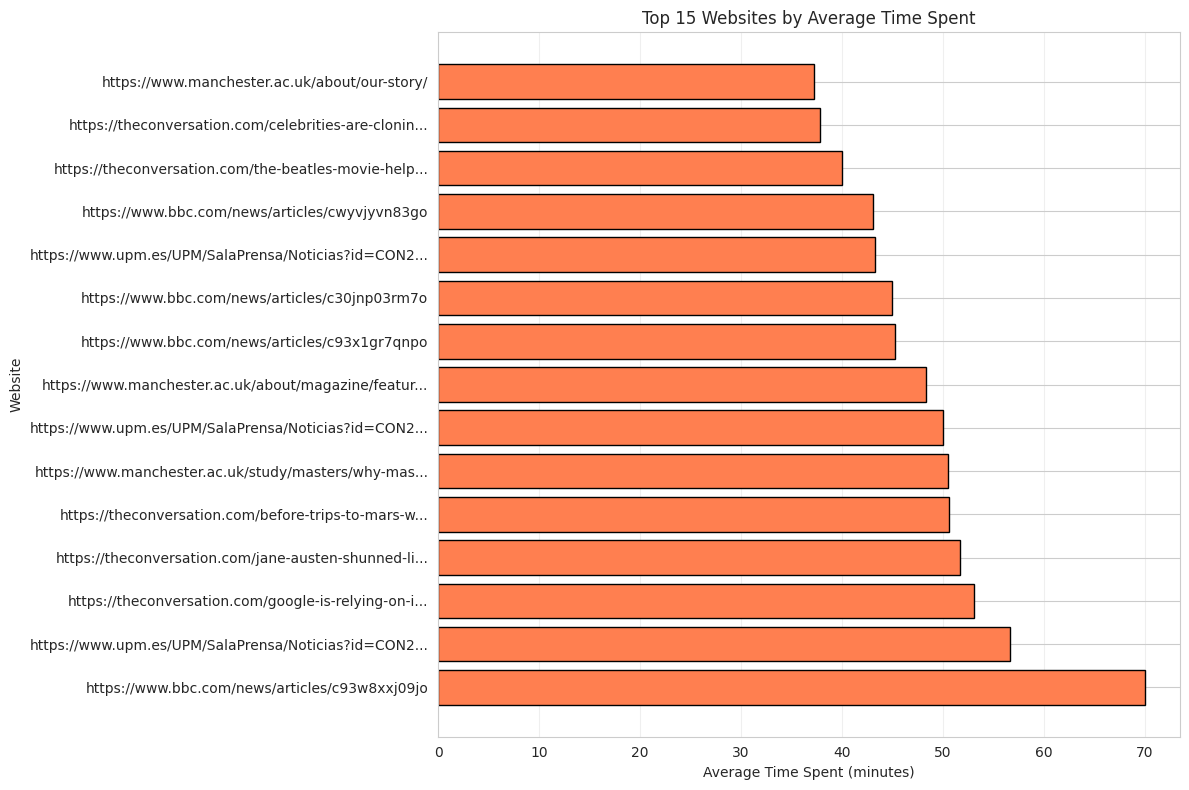

In [334]:
# Visualization: Horizontal bar chart of time by website
plt.figure(figsize=(12, 8))
websites_short = [url[:50] + '...' if len(url) > 50 else url for url in time_by_web.index]
plt.barh(range(len(time_by_web)), time_by_web['mean'], color='coral', edgecolor='black')
plt.yticks(range(len(time_by_web)), websites_short)
plt.xlabel('Average Time Spent (minutes)')
plt.ylabel('Website')
plt.title('Top 15 Websites by Average Time Spent')
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

## Section 4: Tool Usage Analysis

### 4.1 Overall Tool Distribution

In [335]:
# Tool usage counts and percentages
total_entries = len(df_clean)
tool_usage = pd.DataFrame(df_clean['Tool used'].value_counts()).rename(columns={'count': 'Total'})
tool_usage['Percentage'] = ((tool_usage['Total'] / total_entries) * 100).round(2)

print("Tool Usage Distribution:")
print(tool_usage)

Tool Usage Distribution:
           Total  Percentage
Tool used                   
ChatGPT      835       48.66
Gemini       731       42.60
Claude        90        5.24
Copilot       60        3.50


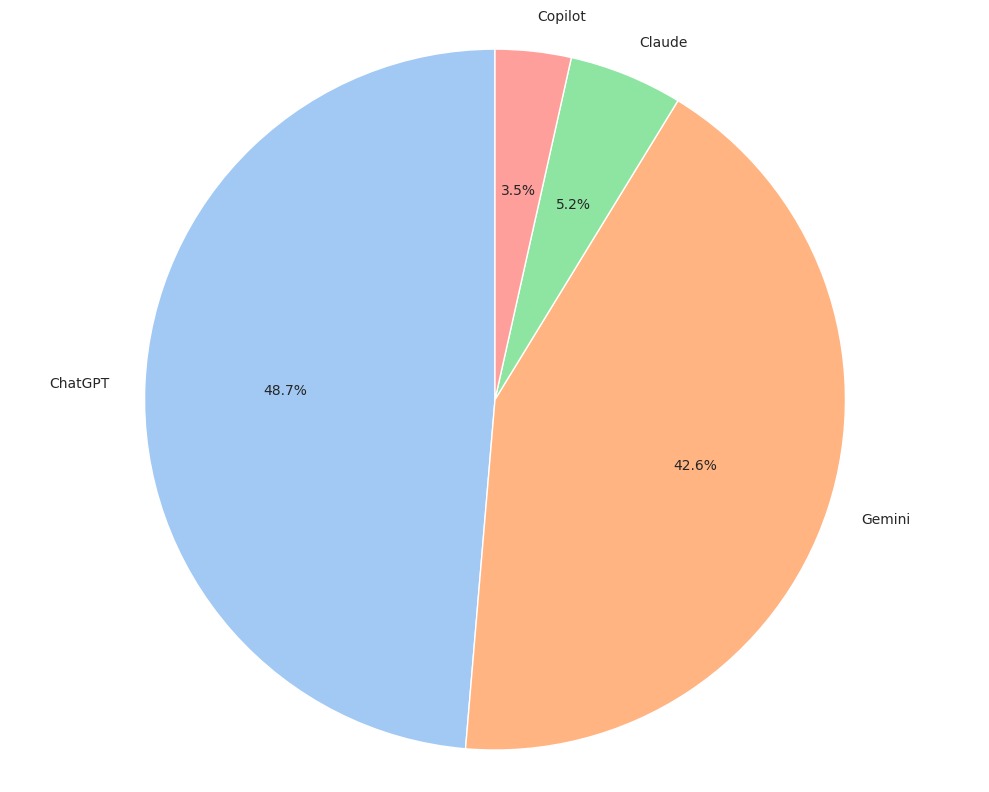

In [336]:
# Visualization: Pie chart of tool distribution (main tools only)
main_tool_usage = tool_usage[tool_usage.index.isin(main_tools)]

plt.figure(figsize=(10, 8))
plt.pie(main_tool_usage['Total'], labels=main_tool_usage.index, autopct='%1.1f%%', 
        startangle=90, colors=sns.color_palette('pastel'))
# plt.title('Distribution of Main Tool Usage')
plt.axis('equal')
plt.tight_layout()
plt.show()

### 4.2 Tool Usage by Group

In [337]:
# Cross-tabulation of groups vs tools (main tools only)
df_main_tools = df_clean[df_clean['Tool used'].isin(main_tools)]
tool_by_group = pd.crosstab(df_main_tools['Group'], df_main_tools['Tool used'])

print("Tool Usage by Group (first 10 groups):")
print(tool_by_group.head(10))

Tool Usage by Group (first 10 groups):
Tool used  ChatGPT  Claude  Copilot  Gemini
Group                                      
1               15       0       30       0
2               15       0        0       0
3               45       0        0      45
4               30       0        0      15
5               30       0        0      15
6                0      15        0      30
7               45       0        0      45
8                0       0        0      15
9               29       0        0      15
10              45       0        0      45


<Figure size 1400x600 with 0 Axes>

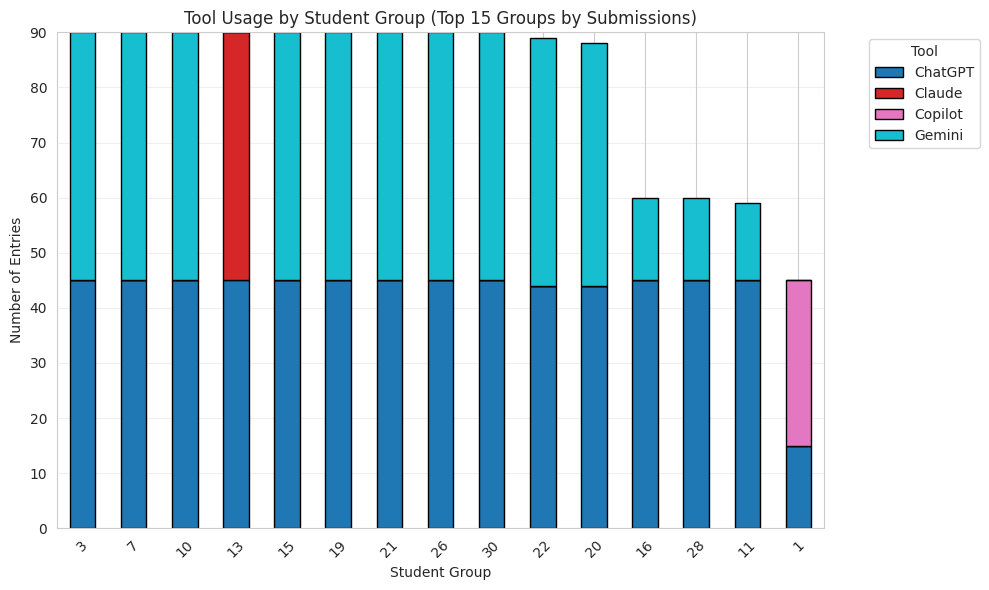

In [338]:
# Visualization: Stacked bar chart for top 15 groups
top_15_groups = tool_by_group.sum(axis=1).nlargest(15).index
tool_by_group_top = tool_by_group.loc[top_15_groups]

plt.figure(figsize=(14, 6))
tool_by_group_top.plot(kind='bar', stacked=True, colormap='tab10', edgecolor='black')
plt.xlabel('Student Group')
plt.ylabel('Number of Entries')
plt.title('Tool Usage by Student Group (Top 15 Groups by Submissions)')
plt.legend(title='Tool', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## Section 5: Tool Accuracy Analysis

### Research Question 3: Which elements can LLMs identify easily?
### Research Question 4: Which tool is most accurate?

### 5.1 Value Category Distribution

In [339]:
# Overall distribution of value categories
value_counts = df_clean['Value'].value_counts()
value_percentages = ((value_counts / len(df_clean)) * 100).round(2)

value_summary = pd.DataFrame({
    'Count': value_counts,
    'Percentage': value_percentages
})

print("Distribution of Detection Results:")
print(value_summary)

Distribution of Detection Results:
                                               Count  Percentage
Value                                                           
Identified by the tool                          1167       68.01
Not identified by the tool                       302       17.60
Partially identified by the tool                 157        9.15
Identified by the evaluator (in a manual way)     84        4.90
Unknown                                            6        0.35


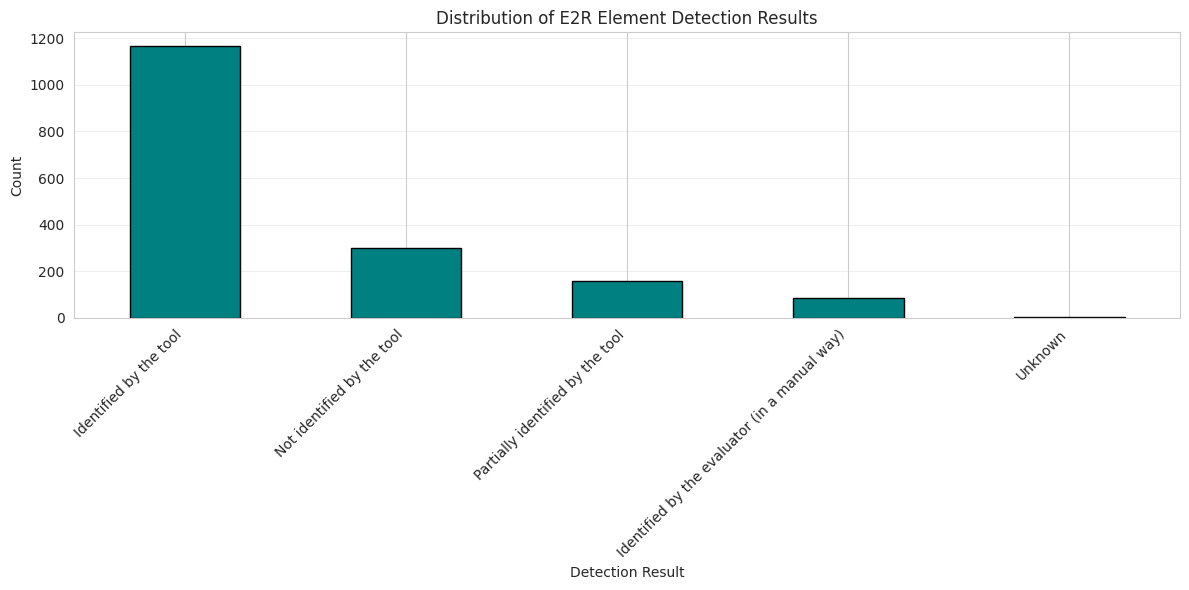

In [340]:
# Visualization: Bar chart of value categories
plt.figure(figsize=(12, 6))
value_counts.plot(kind='bar', color='teal', edgecolor='black')
plt.xlabel('Detection Result')
plt.ylabel('Count')
plt.title('Distribution of E2R Element Detection Results')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

### 5.2 Accuracy by Tool

In [341]:
# Calculate accuracy metrics for each main tool
df_main_tools = df_clean[df_clean['Tool used'].isin(main_tools)]

accuracy_by_tool = pd.crosstab(df_main_tools['Tool used'], df_main_tools['Value'], normalize='index') * 100
accuracy_by_tool = accuracy_by_tool.round(2)

print("Detection Performance by Tool (% of total entries per tool):")
print(accuracy_by_tool)

Detection Performance by Tool (% of total entries per tool):
Value      Identified by the evaluator (in a manual way)  Identified by the tool  Not identified by the tool  Partially identified by the tool  Unknown
Tool used                                                                                                                                              
ChatGPT                                             4.91                   69.34                       16.89                              8.14     0.72
Claude                                              8.89                   65.56                       17.78                              7.78     0.00
Copilot                                            10.00                   46.67                       36.67                              6.67     0.00
Gemini                                              3.97                   68.54                       16.83                             10.67     0.00


In [342]:
# Statistical test: Chi-square test for tool effectiveness
contingency_table = pd.crosstab(df_main_tools['Tool used'], df_main_tools['Value'])
chi2, p_value, dof, expected = stats.chi2_contingency(contingency_table)

print(f"Chi-Square Test for Tool Effectiveness:")
print(f"Chi-square statistic: {chi2:.4f}")
print(f"p-value: {p_value:.4f}")
print(f"Degrees of freedom: {dof}")
print(f"\nConclusion: {'Significant difference' if p_value < 0.05 else 'No significant difference'} in tool performance (α=0.05)")

Chi-Square Test for Tool Effectiveness:
Chi-square statistic: 34.3362
p-value: 0.0006
Degrees of freedom: 12

Conclusion: Significant difference in tool performance (α=0.05)


<Figure size 1200x600 with 0 Axes>

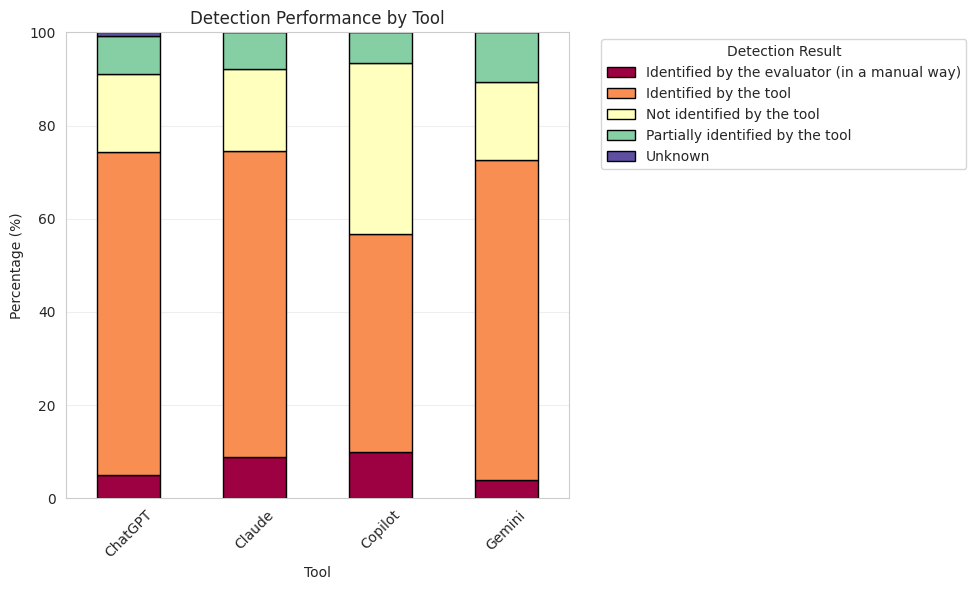

In [343]:
# Visualization: Stacked bar chart of detection results by tool
plt.figure(figsize=(12, 6))
accuracy_by_tool.plot(kind='bar', stacked=True, colormap='Spectral', edgecolor='black')
plt.xlabel('Tool')
plt.ylabel('Percentage (%)')
plt.title('Detection Performance by Tool')
plt.legend(title='Detection Result', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

### 5.3 Detection Rate by E2R Element

In [344]:
# Calculate detection rates for each element
element_detection = pd.crosstab(df_clean['Elements to be identified'], df_clean['Value'], normalize='index') * 100
element_detection = element_detection.round(2)

# Calculate automated detection rate (identified by tool)
if 'Identified by the tool' in element_detection.columns:
    element_detection['Auto_Detection_Rate'] = element_detection['Identified by the tool']
else:
    element_detection['Auto_Detection_Rate'] = 0

element_detection = element_detection.sort_values('Auto_Detection_Rate', ascending=False)

print("Detection Rates by E2R Element (sorted by automated detection rate):")
print(element_detection.head(15))

Detection Rates by E2R Element (sorted by automated detection rate):
Value                                               Identified by the evaluator (in a manual way)  Identified by the tool  Not identified by the tool  Partially identified by the tool  Unknown  Auto_Detection_Rate
Elements to be identified                                                                                                                                                                                            
Adverbs ending in “-ly”                                                                      0.00                  100.00                        0.00                              0.00     0.00               100.00
Gerund forms                                                                                 1.74                   84.35                        3.48                              9.57     0.87                84.35
Adverbs ending in '-ly'                                                    

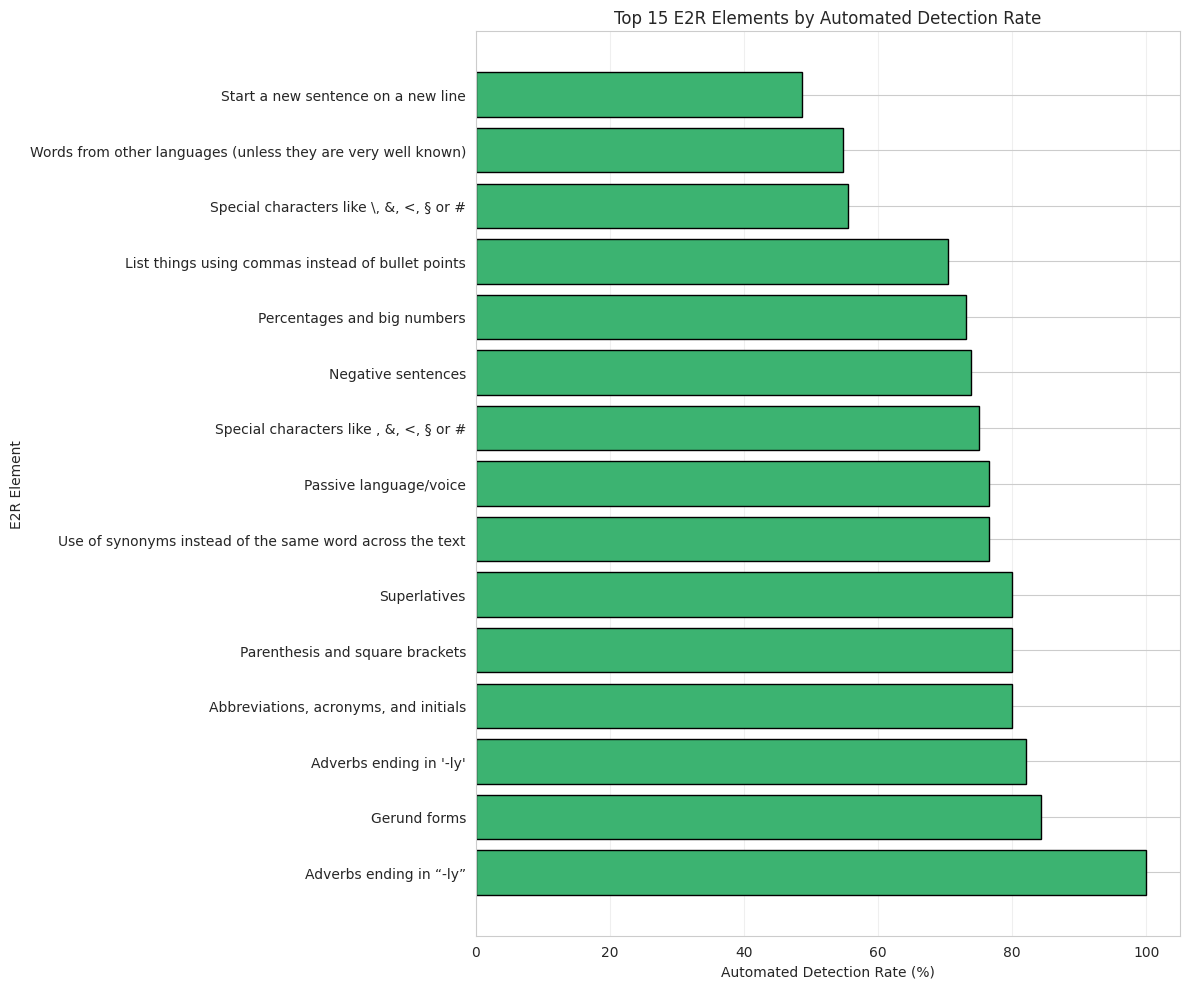

In [345]:
# Visualization: Horizontal bar chart of detection rates
plt.figure(figsize=(12, 10))
top_elements = element_detection['Auto_Detection_Rate'].head(15)
plt.barh(range(len(top_elements)), top_elements, color='mediumseagreen', edgecolor='black')
plt.yticks(range(len(top_elements)), top_elements.index)
plt.xlabel('Automated Detection Rate (%)')
plt.ylabel('E2R Element')
plt.title('Top 15 E2R Elements by Automated Detection Rate')
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

### 5.4 Tool Performance Heatmap

In [346]:
# Create pivot table for heatmap (tool × element)
df_identified = df_main_tools[df_main_tools['Value'] == 'Identified by the tool']
tool_element_counts = pd.crosstab(df_main_tools['Tool used'], df_main_tools['Elements to be identified'])
tool_element_identified = pd.crosstab(df_identified['Tool used'], df_identified['Elements to be identified'])

# Calculate detection rate percentage
tool_element_rate = (tool_element_identified / tool_element_counts * 100).fillna(0).round(1)

# Select top 10 most common elements for readability
top_10_elements = df_clean['Elements to be identified'].value_counts().head(10).index
tool_element_rate_top = tool_element_rate[top_10_elements]

print("Tool Performance on Top 10 Most Common E2R Elements (% detected):")
print(tool_element_rate_top)

Tool Performance on Top 10 Most Common E2R Elements (% detected):
Elements to be identified  Parenthesis and square brackets  Abbreviations, acronyms, and initials  Percentages and big numbers  Passive language/voice  Negative sentences  Gerund forms  Start a new sentence on a new line  Words from other languages (unless they are very well known)  Use of synonyms instead of the same word across the text  Superlatives
Tool used                                                                                                                                                                                                                                                                                                                                                         
ChatGPT                                               83.9                                   80.4                         67.9                    71.4                73.2          82.1                                48.2    

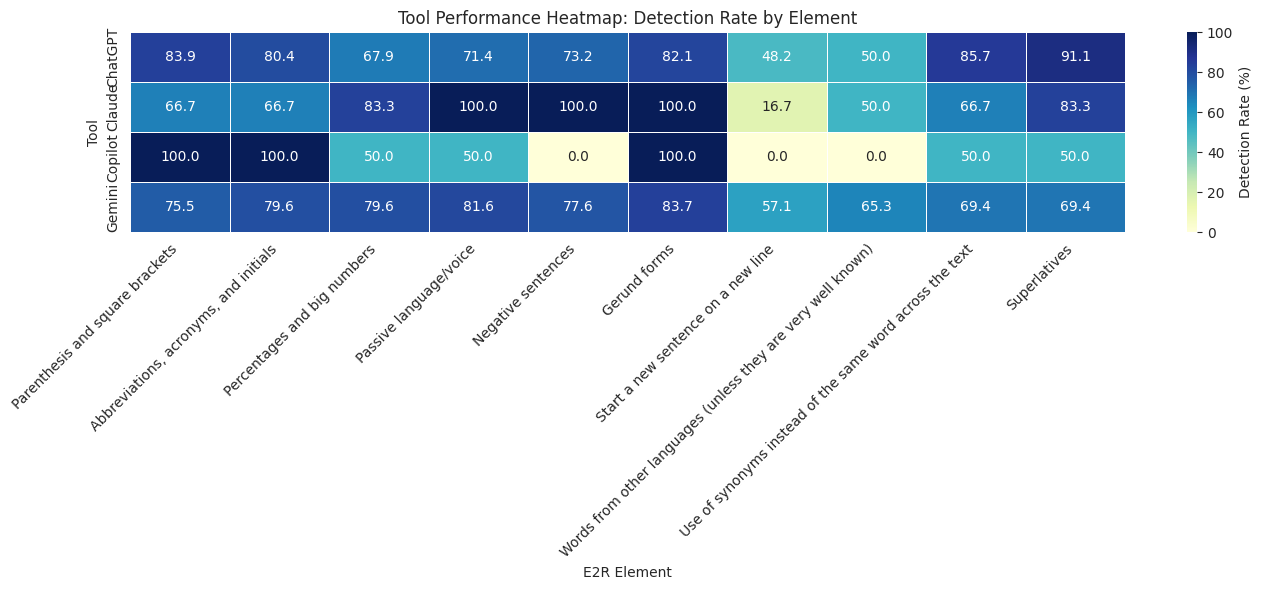

In [347]:
# Visualization: Heatmap of tool performance
plt.figure(figsize=(14, 6))
sns.heatmap(tool_element_rate_top, annot=True, fmt='.1f', cmap='YlGnBu', 
            linewidths=0.5, cbar_kws={'label': 'Detection Rate (%)'})
plt.xlabel('E2R Element')
plt.ylabel('Tool')
plt.title('Tool Performance Heatmap: Detection Rate by Element')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## Section 6: E2R Element Analysis

### Research Question 5: What are the most common E2R violations?

### 6.1 Most Common E2R Violations

In [348]:
# Count frequency of each element
element_frequency = df_clean['Elements to be identified'].value_counts().head(15)

print("Top 15 Most Common E2R Elements:")
print(element_frequency)

Top 15 Most Common E2R Elements:
Elements to be identified
Parenthesis and square brackets                                 115
Abbreviations, acronyms, and initials                           115
Percentages and big numbers                                     115
Passive language/voice                                          115
Negative sentences                                              115
Gerund forms                                                    115
Start a new sentence on a new line                              115
Words from other languages (unless they are very well known)    115
Use of synonyms instead of the same word across the text        115
Superlatives                                                    115
Semicolon                                                       114
etc.' and suspension points                                     111
Adverbs ending in '-ly'                                         111
Special characters like \, &, <, § or #                  

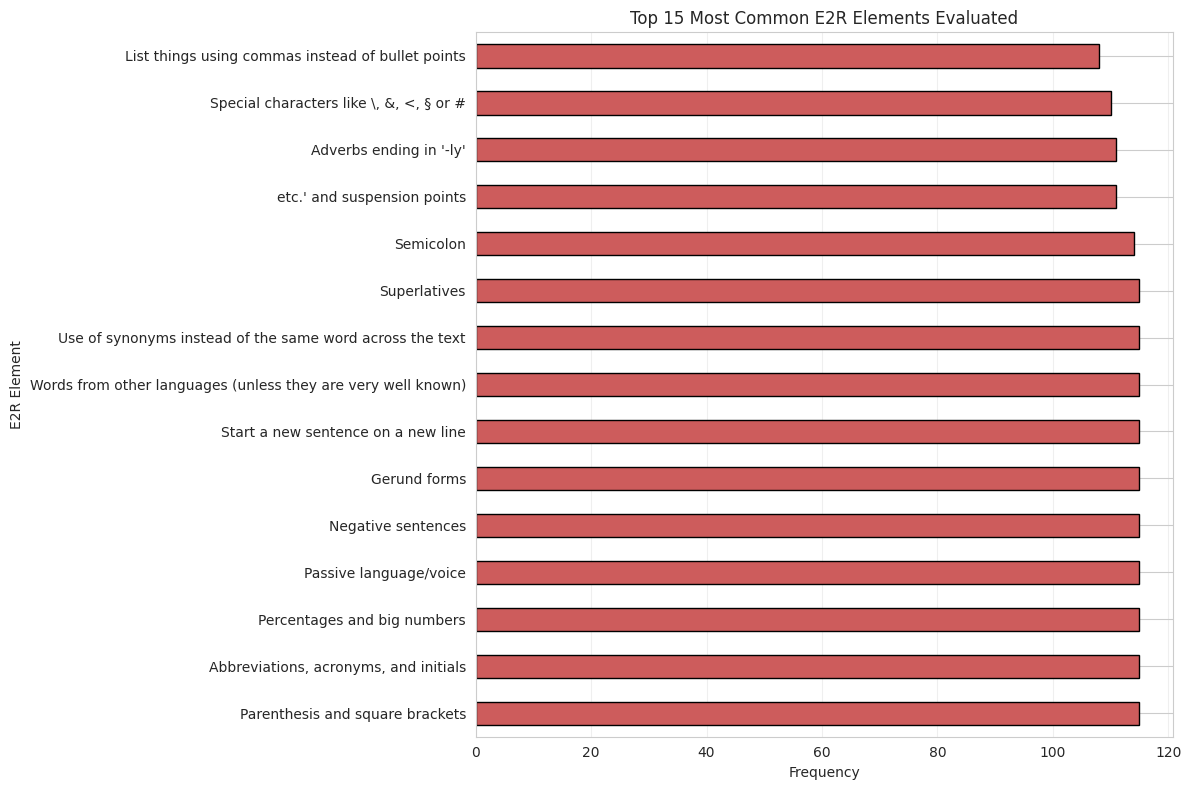

In [349]:
# Visualization: Bar chart of most common elements
plt.figure(figsize=(12, 8))
element_frequency.plot(kind='barh', color='indianred', edgecolor='black')
plt.xlabel('Frequency')
plt.ylabel('E2R Element')
plt.title('Top 15 Most Common E2R Elements Evaluated')
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

### 6.2 Elements by Category

In [350]:
# Count violations by E2R category
category_counts = df_clean['E2R_Category'].value_counts()

print("E2R Violations by Category:")
print(category_counts)

E2R Violations by Category:
E2R_Category
Spelling       688
Grammar        460
Vocabulary     460
Composition    108
Name: count, dtype: int64


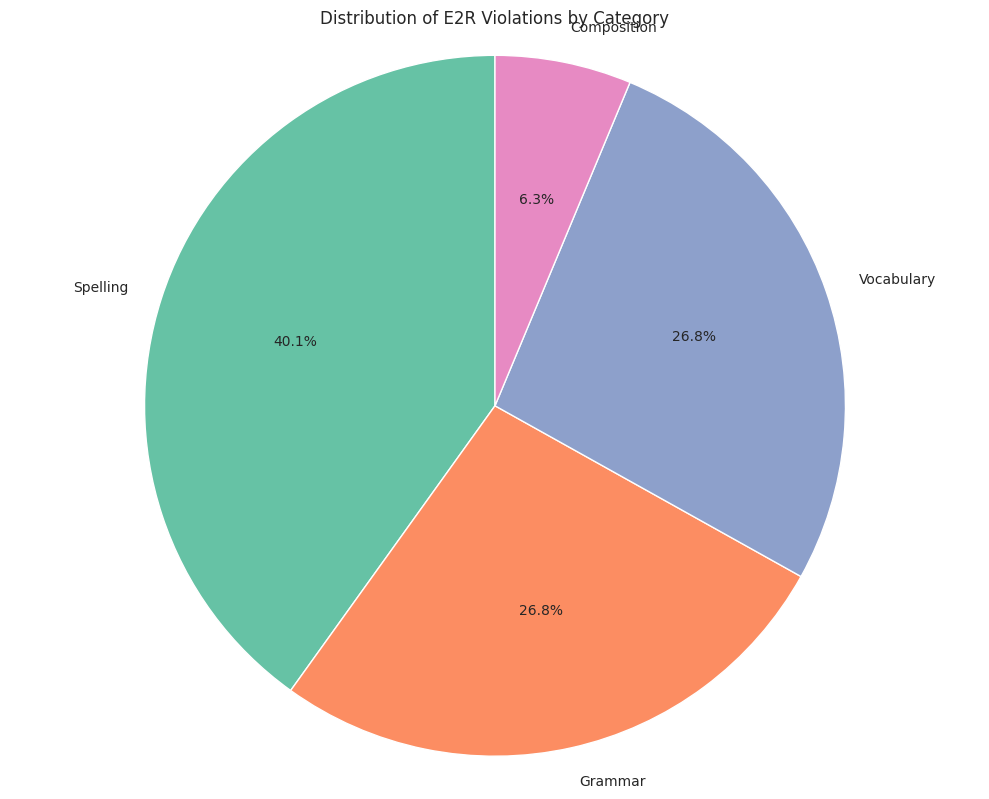

In [351]:
# Visualization: Pie chart of violations by category
plt.figure(figsize=(10, 8))
plt.pie(category_counts, labels=category_counts.index, autopct='%1.1f%%', 
        startangle=90, colors=sns.color_palette('Set2'))
plt.title('Distribution of E2R Violations by Category')
plt.axis('equal')
plt.tight_layout()
plt.show()

### 6.3 Detection Difficulty Analysis

In [352]:
# Combine frequency and detection rate to identify hard-to-detect elements
element_freq_all = df_clean['Elements to be identified'].value_counts()
element_stats = pd.DataFrame({
    'Frequency': element_freq_all,
    'Detection_Rate': element_detection.get('Auto_Detection_Rate', 0)
}).fillna(0)

# Filter for elements with at least 20 occurrences
element_stats = element_stats[element_stats['Frequency'] >= 20]
element_stats = element_stats.sort_values('Detection_Rate', ascending=True)

print("Elements with Low Detection Rates (min 20 occurrences):")
print(element_stats.head(10))

Elements with Low Detection Rates (min 20 occurrences):
                                                    Frequency  Detection_Rate
Elements to be identified                                                    
etc.' and suspension points                               111           39.64
Semicolon                                                 114           44.74
Start a new sentence on a new line                        115           48.70
Words from other languages (unless they are ver...        115           54.78
Special characters like \, &, <, § or #                   110           55.45
List things using commas instead of bullet points         108           70.37
Percentages and big numbers                               115           73.04
Negative sentences                                        115           73.91
Passive language/voice                                    115           76.52
Use of synonyms instead of the same word across...        115           76.52


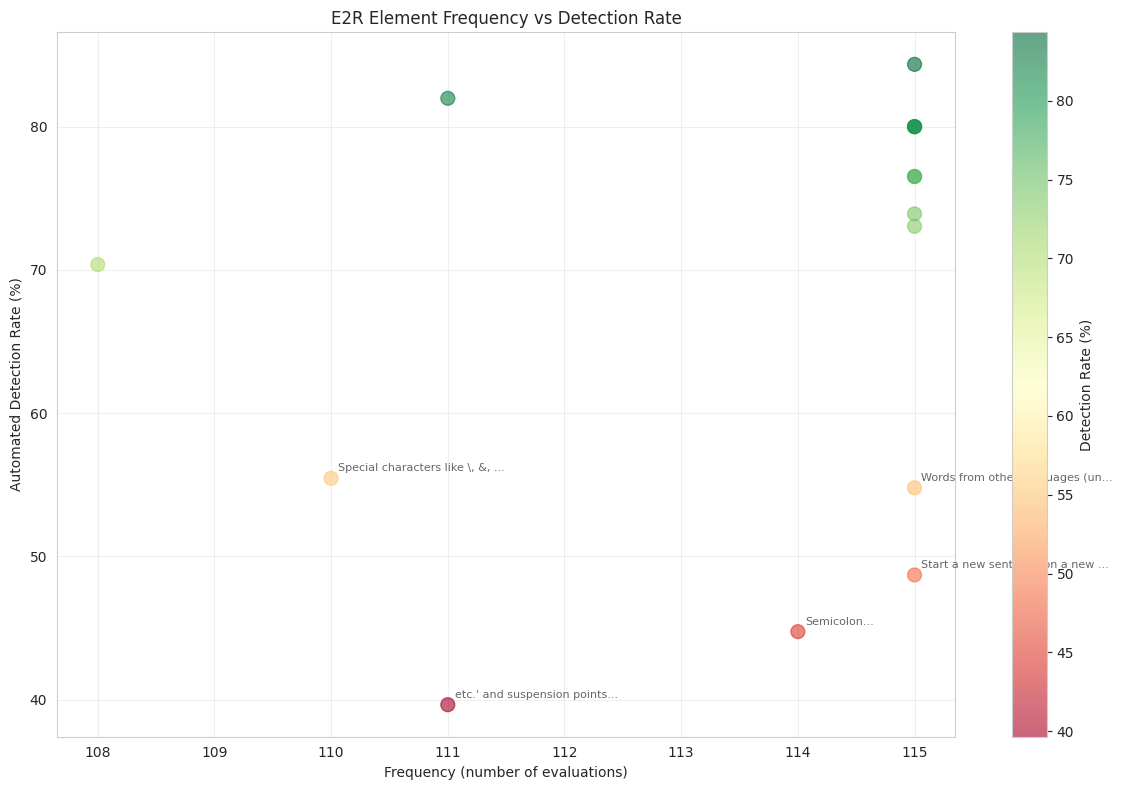

In [353]:
# Visualization: Scatter plot of frequency vs detection rate
plt.figure(figsize=(12, 8))
plt.scatter(element_stats['Frequency'], element_stats['Detection_Rate'], 
            s=100, alpha=0.6, c=element_stats['Detection_Rate'], cmap='RdYlGn')
plt.colorbar(label='Detection Rate (%)')
plt.xlabel('Frequency (number of evaluations)')
plt.ylabel('Automated Detection Rate (%)')
plt.title('E2R Element Frequency vs Detection Rate')
plt.grid(alpha=0.3)

# Annotate some key points
for idx in element_stats.head(5).index:
    plt.annotate(idx[:30] + '...', 
                xy=(element_stats.loc[idx, 'Frequency'], element_stats.loc[idx, 'Detection_Rate']),
                xytext=(5, 5), textcoords='offset points', fontsize=8, alpha=0.7)

plt.tight_layout()
plt.show()

## Section 7: Group Comparison Analysis

### Research Question 6: Are there differences between student groups?

### 7.1 Submissions per Group

In [354]:
# Count submissions per group
submissions_per_group = df_clean['Group'].value_counts().sort_index()

print(f"Total number of groups: {df_clean['Group'].nunique()}")
print(f"Average submissions per group: {submissions_per_group.mean():.2f}")
print(f"Median submissions per group: {submissions_per_group.median():.2f}")
print(f"\nTop 10 groups by submission count:")
print(submissions_per_group.head(10))

Total number of groups: 29
Average submissions per group: 59.17
Median submissions per group: 45.00

Top 10 groups by submission count:
Group
1     45
2     15
3     90
4     45
5     45
6     45
7     90
8     15
9     44
10    90
Name: count, dtype: int64


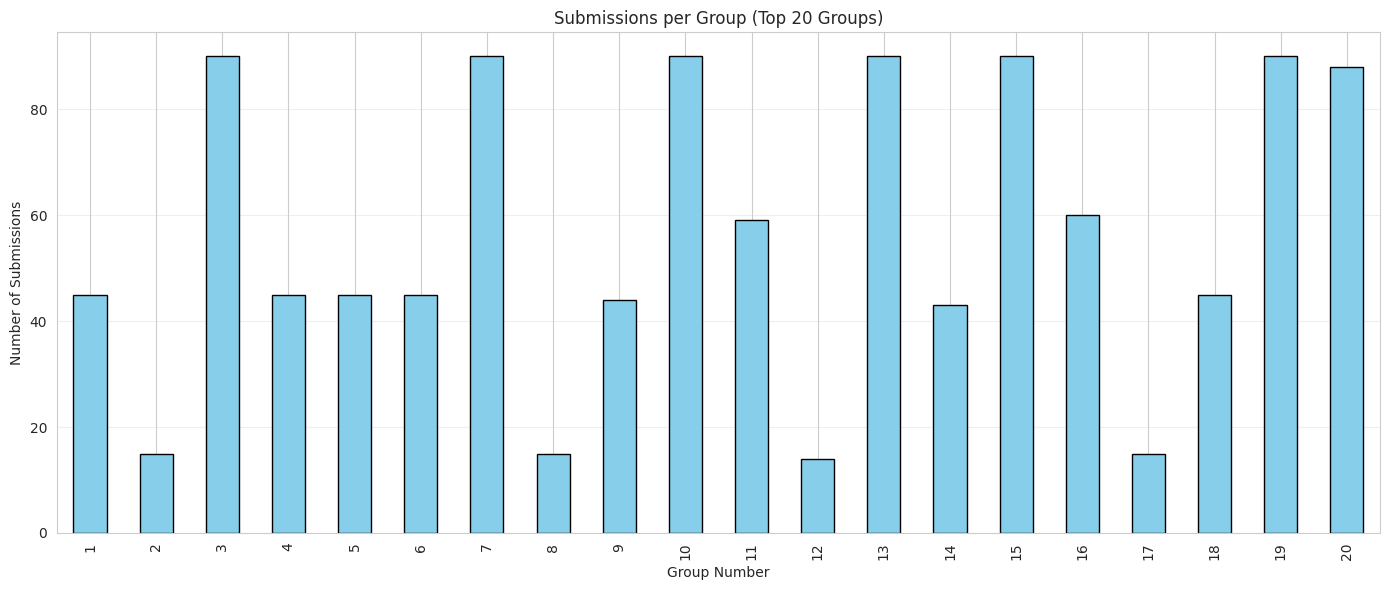

In [355]:
# Visualization: Bar chart of submissions per group
plt.figure(figsize=(14, 6))
submissions_per_group.head(20).plot(kind='bar', color='skyblue', edgecolor='black')
plt.xlabel('Group Number')
plt.ylabel('Number of Submissions')
plt.title('Submissions per Group (Top 20 Groups)')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

### 7.2 Performance Metrics by Group

In [356]:
# Calculate performance metrics by group
group_performance = df_clean.groupby('Group').agg({
    'Time Spent': ['mean', 'median'],
    'Tool used': lambda x: x.mode()[0] if len(x.mode()) > 0 else 'N/A',  # Most common tool
    'Value': 'count'
}).round(2)

group_performance.columns = ['Avg_Time', 'Median_Time', 'Preferred_Tool', 'Total_Entries']
group_performance = group_performance.sort_values('Total_Entries', ascending=False)

print("Group Performance Summary (Top 15 by entries):")
print(group_performance.head(15))

Group Performance Summary (Top 15 by entries):
       Avg_Time  Median_Time Preferred_Tool  Total_Entries
Group                                                     
3          0.00          0.0        ChatGPT             90
10        45.00         45.0        ChatGPT             90
13        52.50         52.5        ChatGPT             90
7         14.50         14.0        ChatGPT             90
15        76.67         65.0        ChatGPT             90
26        46.67         45.0        ChatGPT             90
21        30.00         30.0        ChatGPT             90
19        45.00         45.0        ChatGPT             90
30        30.00         30.0        ChatGPT             90
22         6.74         10.0         Gemini             89
20        80.45        120.0        ChatGPT             88
16        52.50         60.0        ChatGPT             60
28        52.50         60.0        ChatGPT             60
11        31.36         30.0        ChatGPT             59
27       

### 7.3 Statistical Comparison

In [357]:
# ANOVA test for time differences across groups (top 10 groups by size)
top_10_groups_list = submissions_per_group.nlargest(10).index.tolist()
group_time_data = [df_clean[df_clean['Group'] == g]['Time Spent'].values 
                   for g in top_10_groups_list]

f_stat_groups, p_value_groups = stats.f_oneway(*group_time_data)

print(f"ANOVA Test for Time Differences Across Groups (Top 10):")
print(f"F-statistic: {f_stat_groups:.4f}")
print(f"p-value: {p_value_groups:.4f}")
print(f"\nConclusion: {'Significant difference' if p_value_groups < 0.05 else 'No significant difference'} in time spent across groups (α=0.05)")

ANOVA Test for Time Differences Across Groups (Top 10):
F-statistic: 342.3571
p-value: 0.0000

Conclusion: Significant difference in time spent across groups (α=0.05)


In [358]:
# Chi-square test for tool preference by group
df_main_tools_groups = df_clean[df_clean['Tool used'].isin(main_tools)]
df_top_groups_main = df_main_tools_groups[df_main_tools_groups['Group'].isin(top_10_groups_list)]

contingency_groups = pd.crosstab(df_top_groups_main['Group'], df_top_groups_main['Tool used'])
chi2_groups, p_value_chi_groups, dof_groups, _ = stats.chi2_contingency(contingency_groups)

print(f"\nChi-Square Test for Tool Preference by Group:")
print(f"Chi-square statistic: {chi2_groups:.4f}")
print(f"p-value: {p_value_chi_groups:.4f}")
print(f"Degrees of freedom: {dof_groups}")
print(f"\nConclusion: {'Significant difference' if p_value_chi_groups < 0.05 else 'No significant difference'} in tool preference across groups (α=0.05)")


Chi-Square Test for Tool Preference by Group:
Chi-square statistic: 449.5662
p-value: 0.0000
Degrees of freedom: 18

Conclusion: Significant difference in tool preference across groups (α=0.05)


### 7.4 Group Clustering

In [359]:
# Categorize groups by performance
median_time = group_performance['Avg_Time'].median()
group_performance['Speed_Category'] = group_performance['Avg_Time'].apply(
    lambda x: 'Fast' if x < median_time else 'Slow'
)

print("Group Categories by Speed:")
print(group_performance['Speed_Category'].value_counts())
print("\nFastest Groups:")
print(group_performance.nsmallest(5, 'Avg_Time')[['Avg_Time', 'Preferred_Tool', 'Total_Entries']])
print("\nSlowest Groups:")
print(group_performance.nlargest(5, 'Avg_Time')[['Avg_Time', 'Preferred_Tool', 'Total_Entries']])

Group Categories by Speed:
Speed_Category
Slow    15
Fast    14
Name: count, dtype: int64

Fastest Groups:
       Avg_Time Preferred_Tool  Total_Entries
Group                                        
3          0.00        ChatGPT             90
22         6.74         Gemini             89
14        10.00         Gemini             43
7         14.50        ChatGPT             90
2         20.00        ChatGPT             15

Slowest Groups:
       Avg_Time Preferred_Tool  Total_Entries
Group                                        
9         90.00        ChatGPT             44
20        80.45        ChatGPT             88
15        76.67        ChatGPT             90
5         70.00        ChatGPT             45
8         60.00         Gemini             15


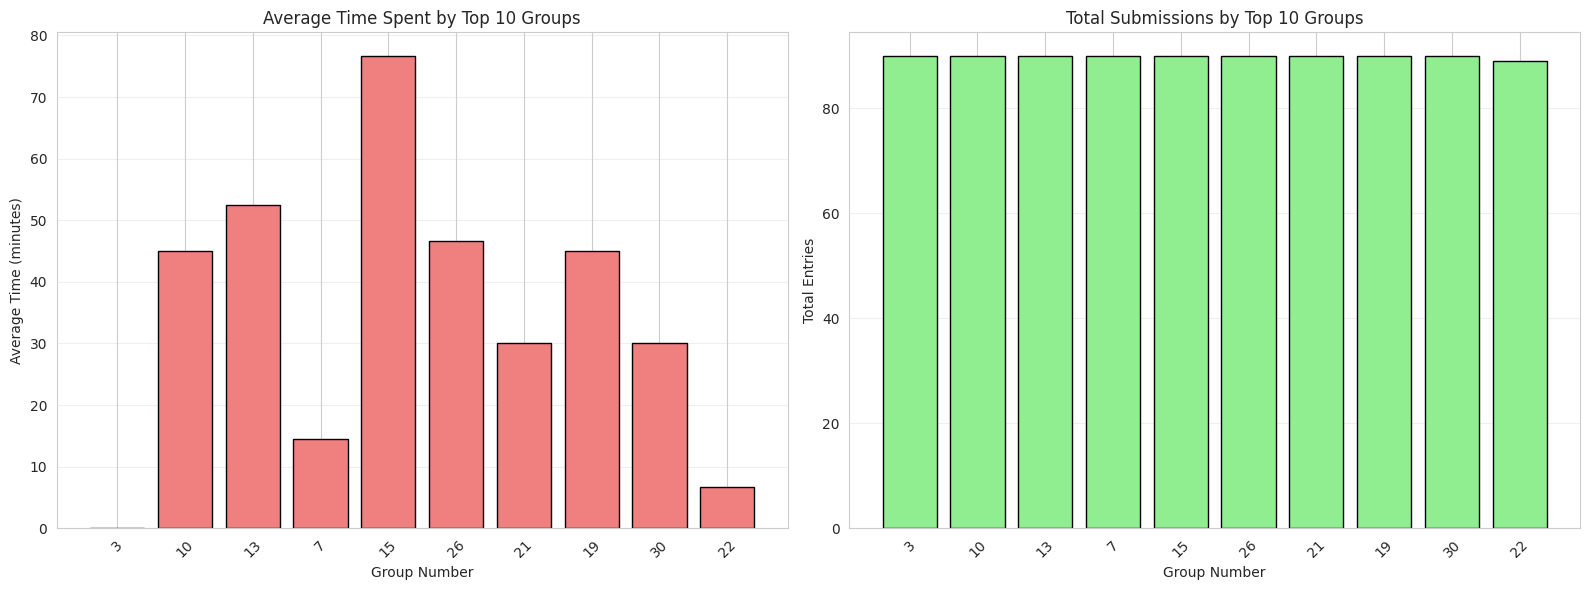

In [360]:
# Visualization: Grouped bar chart comparing key metrics
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Average time by top 10 groups
top_10_perf = group_performance.head(10)
axes[0].bar(range(len(top_10_perf)), top_10_perf['Avg_Time'], color='lightcoral', edgecolor='black')
axes[0].set_xticks(range(len(top_10_perf)))
axes[0].set_xticklabels(top_10_perf.index, rotation=45)
axes[0].set_xlabel('Group Number')
axes[0].set_ylabel('Average Time (minutes)')
axes[0].set_title('Average Time Spent by Top 10 Groups')
axes[0].grid(axis='y', alpha=0.3)

# Total entries by top 10 groups
axes[1].bar(range(len(top_10_perf)), top_10_perf['Total_Entries'], color='lightgreen', edgecolor='black')
axes[1].set_xticks(range(len(top_10_perf)))
axes[1].set_xticklabels(top_10_perf.index, rotation=45)
axes[1].set_xlabel('Group Number')
axes[1].set_ylabel('Total Entries')
axes[1].set_title('Total Submissions by Top 10 Groups')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

## Section 8: Website Analysis

### 8.1 Most Analyzed Websites

In [361]:
# Count frequency of each website
website_counts = df_clean['Web'].value_counts().head(15)

print("Top 15 Most Analyzed Websites:")
for i, (url, count) in enumerate(website_counts.items(), 1):
    print(f"{i}. [{count} evaluations] {url[:80]}..." if len(url) > 80 else f"{i}. [{count} evaluations] {url}")

Top 15 Most Analyzed Websites:
1. [180 evaluations] https://www.manchester.ac.uk/about/magazine/features/life-impact-sear-family/
2. [179 evaluations] https://theconversation.com/google-is-relying-on-its-own-chips-for-its-ai-system...
3. [150 evaluations] https://www.manchester.ac.uk/study/masters/why-masters-study/
4. [149 evaluations] https://www.bbc.com/news/articles/c93x1gr7qnpo
5. [120 evaluations] https://www.manchester.ac.uk/about/our-story/
6. [105 evaluations] https://theconversation.com/celebrities-are-cloning-their-pets-but-the-procedure...
7. [104 evaluations] https://www.bbc.com/news/articles/cwyvjyvn83go
8. [90 evaluations] https://www.bbc.com/news/articles/c93w8xxj09jo
9. [73 evaluations] https://www.bbc.com/mundo/articles/c4g6qqy9jl9o
10. [60 evaluations] https://www.bbc.com/news/articles/c3r78peyzzlo
11. [59 evaluations] https://theconversation.com/before-trips-to-mars-we-need-better-protection-from-...
12. [45 evaluations] https://theconversation.com/activism-doesnt-a

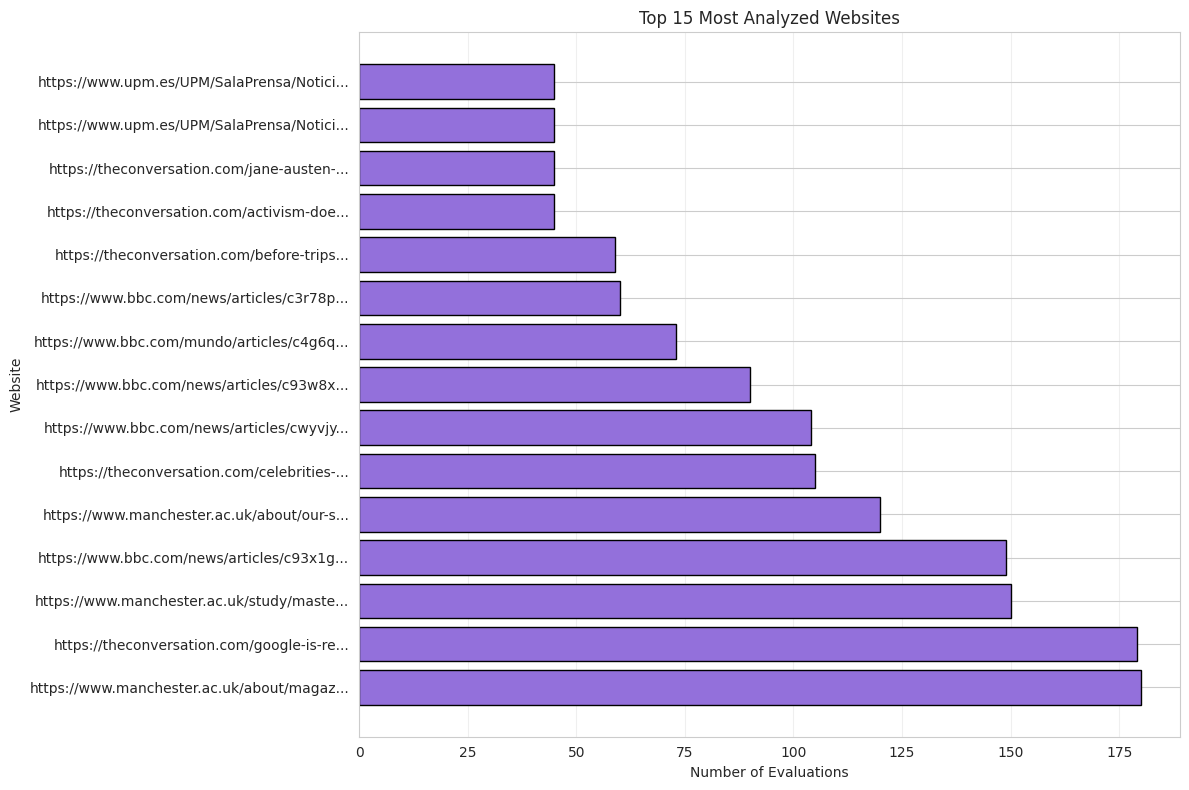

In [362]:
# Visualization: Bar chart of most analyzed websites
plt.figure(figsize=(12, 8))
websites_short = [url[:40] + '...' if len(url) > 40 else url for url in website_counts.index]
plt.barh(range(len(website_counts)), website_counts.values, color='mediumpurple', edgecolor='black')
plt.yticks(range(len(website_counts)), websites_short)
plt.xlabel('Number of Evaluations')
plt.ylabel('Website')
plt.title('Top 15 Most Analyzed Websites')
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

### 8.2 Website Domain Analysis

In [363]:
# Extract domain from URLs
def extract_domain(url):
    if pd.isna(url):
        return 'Unknown'
    try:
        parsed = urlparse(url)
        domain = parsed.netloc
        # Remove www. prefix
        if domain.startswith('www.'):
            domain = domain[4:]
        return domain
    except:
        return 'Unknown'

df_clean['Domain'] = df_clean['Web'].apply(extract_domain)

domain_counts = df_clean['Domain'].value_counts().head(15)
print("Top 15 Domains by Evaluation Count:")
print(domain_counts)

Top 15 Domains by Evaluation Count:
Domain
bbc.com                536
theconversation.com    476
manchester.ac.uk       450
upm.es                 150
Unknown                 89
esmadrid.com            15
Name: count, dtype: int64


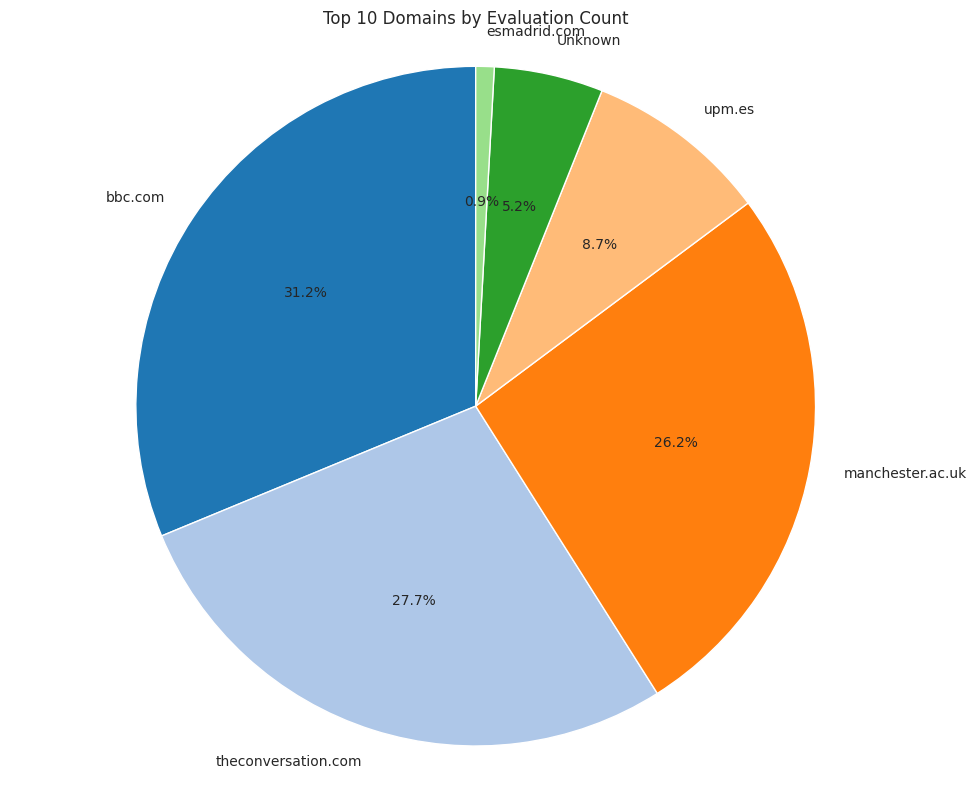

In [364]:
# Visualization: Pie chart of top domains
plt.figure(figsize=(10, 8))
plt.pie(domain_counts.head(10), labels=domain_counts.head(10).index, autopct='%1.1f%%',
        startangle=90, colors=sns.color_palette('tab20'))
plt.title('Top 10 Domains by Evaluation Count')
plt.axis('equal')
plt.tight_layout()
plt.show()

### 8.3 E2R Violations by Website

In [365]:
# Count violations by website (top 10 websites)
top_10_websites = website_counts.head(10).index.tolist()
df_top_websites = df_clean[df_clean['Web'].isin(top_10_websites)]

website_violations = df_top_websites.groupby('Web')['E2R_Category'].value_counts().unstack(fill_value=0)

print("E2R Violations by Category for Top 10 Websites:")
print(website_violations)

E2R Violations by Category for Top 10 Websites:
E2R_Category                                        Composition  Grammar  Spelling  Vocabulary
Web                                                                                           
https://theconversation.com/celebrities-are-clo...            7       28        42          28
https://theconversation.com/google-is-relying-o...           11       48        72          48
https://www.bbc.com/mundo/articles/c4g6qqy9jl9o               5       20        28          20
https://www.bbc.com/news/articles/c3r78peyzzlo                4       16        24          16
https://www.bbc.com/news/articles/c93w8xxj09jo                6       24        36          24
https://www.bbc.com/news/articles/c93x1gr7qnpo                9       40        60          40
https://www.bbc.com/news/articles/cwyvjyvn83go                6       28        42          28
https://www.manchester.ac.uk/about/magazine/fea...           12       48        72          48
ht

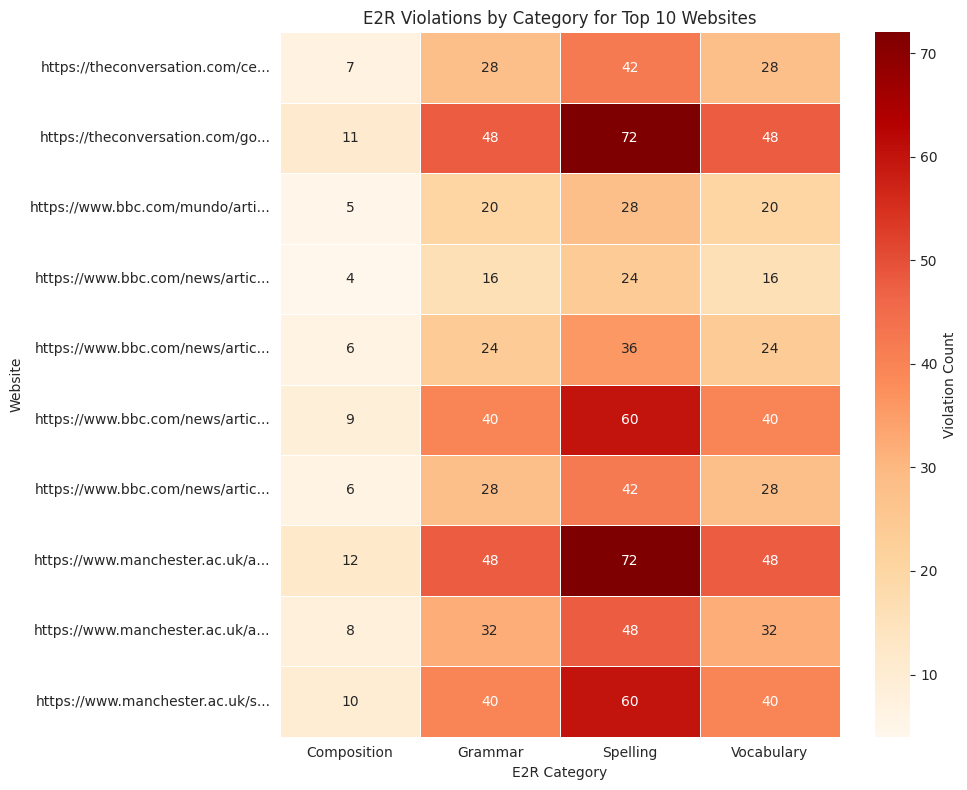

In [366]:
# Visualization: Heatmap of violations by website
plt.figure(figsize=(10, 8))
websites_labels = [url[:30] + '...' if len(url) > 30 else url for url in website_violations.index]
sns.heatmap(website_violations.values, annot=True, fmt='d', cmap='OrRd',
            xticklabels=website_violations.columns,
            yticklabels=websites_labels,
            linewidths=0.5, cbar_kws={'label': 'Violation Count'})
plt.xlabel('E2R Category')
plt.ylabel('Website')
plt.title('E2R Violations by Category for Top 10 Websites')
plt.tight_layout()
plt.show()

### 8.4 Website Difficulty Score

In [367]:
# Calculate difficulty score for each website
website_stats = df_clean.groupby('Web').agg({
    'Value': 'count',  # Total evaluations
    'Time Spent': 'mean',  # Average time
    'Elements to be identified': 'count'  # Total violations checked
}).round(2)

website_stats.columns = ['Total_Evaluations', 'Avg_Time', 'Total_Checks']

# Filter for websites with at least 10 evaluations
website_stats = website_stats[website_stats['Total_Evaluations'] >= 10]

# Calculate difficulty index (normalized combination of time and checks)
website_stats['Difficulty_Index'] = (
    (website_stats['Avg_Time'] / website_stats['Avg_Time'].max() * 50) +
    (website_stats['Total_Checks'] / website_stats['Total_Checks'].max() * 50)
).round(2)

website_stats = website_stats.sort_values('Difficulty_Index', ascending=False)

print("Top 10 Most Difficult Websites (min 10 evaluations):")
for i, (url, row) in enumerate(website_stats.head(10).iterrows(), 1):
    print(f"{i}. Difficulty: {row['Difficulty_Index']:.2f} | Time: {row['Avg_Time']:.1f}min | {url[:60]}..." 
          if len(url) > 60 else f"{i}. Difficulty: {row['Difficulty_Index']:.2f} | Time: {row['Avg_Time']:.1f}min | {url}")

Top 10 Most Difficult Websites (min 10 evaluations):
1. Difficulty: 87.63 | Time: 53.1min | https://theconversation.com/google-is-relying-on-its-own-chi...
2. Difficulty: 84.52 | Time: 48.3min | https://www.manchester.ac.uk/about/magazine/features/life-im...
3. Difficulty: 77.74 | Time: 50.5min | https://www.manchester.ac.uk/study/masters/why-masters-study...
4. Difficulty: 75.00 | Time: 70.0min | https://www.bbc.com/news/articles/c93w8xxj09jo
5. Difficulty: 73.75 | Time: 45.3min | https://www.bbc.com/news/articles/c93x1gr7qnpo
6. Difficulty: 59.94 | Time: 37.2min | https://www.manchester.ac.uk/about/our-story/
7. Difficulty: 59.66 | Time: 43.1min | https://www.bbc.com/news/articles/cwyvjyvn83go
8. Difficulty: 56.21 | Time: 37.9min | https://theconversation.com/celebrities-are-cloning-their-pe...
9. Difficulty: 52.98 | Time: 56.7min | https://www.upm.es/UPM/SalaPrensa/Noticias?id=CON24025&fmt=d...
10. Difficulty: 52.52 | Time: 50.6min | https://theconversation.com/before-trips-to-mars-

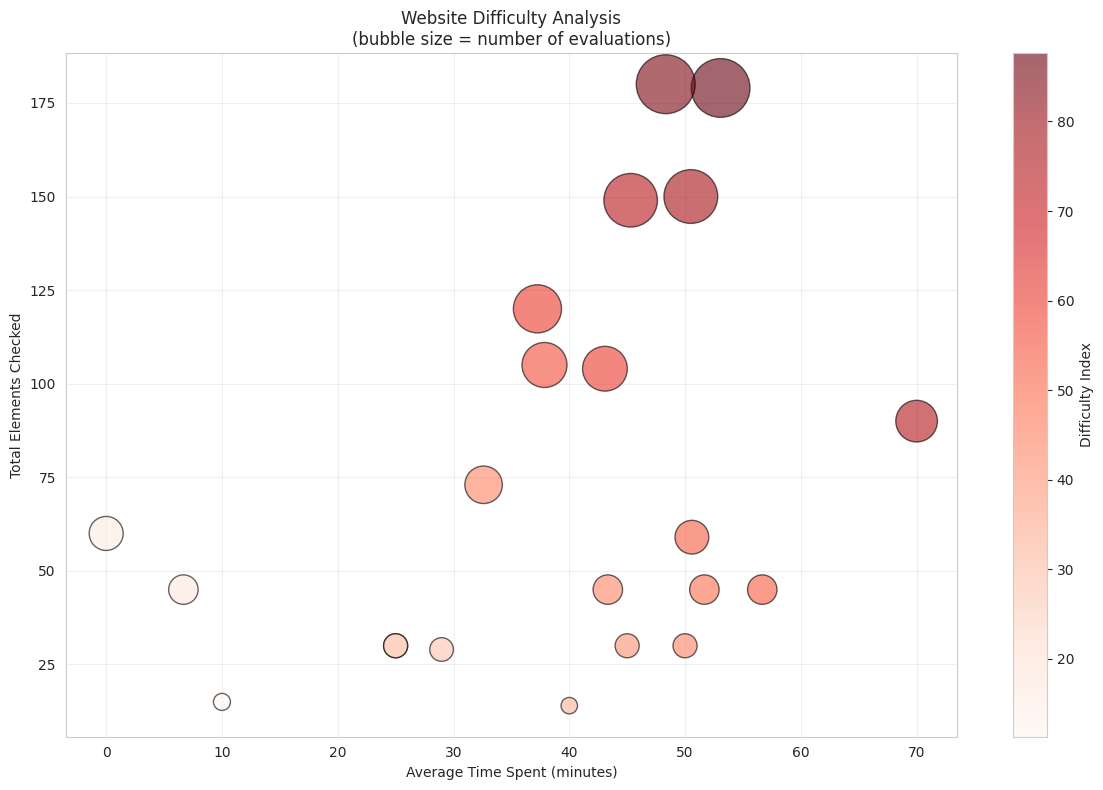

In [368]:
# Visualization: Scatter plot of time vs checks with difficulty score
plt.figure(figsize=(12, 8))
scatter = plt.scatter(website_stats['Avg_Time'], website_stats['Total_Checks'],
                     s=website_stats['Total_Evaluations']*10, 
                     c=website_stats['Difficulty_Index'],
                     cmap='Reds', alpha=0.6, edgecolors='black')
plt.colorbar(scatter, label='Difficulty Index')
plt.xlabel('Average Time Spent (minutes)')
plt.ylabel('Total Elements Checked')
plt.title('Website Difficulty Analysis\n(bubble size = number of evaluations)')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Section 9: Statistical Testing Summary

In [369]:
# Consolidated summary of all statistical tests
print("="*80)
print("STATISTICAL TESTING SUMMARY")
print("="*80)
print("\nSignificance level: α = 0.05")
print("\n" + "-"*80)
print("1. TIME DIFFERENCES ACROSS TOOLS (ANOVA)")
print("-"*80)
print(f"F-statistic: {f_stat:.4f}")
print(f"p-value: {p_value:.4f}")
print(f"Result: {'SIGNIFICANT - Tools differ in time spent' if p_value < 0.05 else 'NOT SIGNIFICANT - No difference in time across tools'}")

print("\n" + "-"*80)
print("2. TOOL EFFECTIVENESS (Chi-Square Test)")
print("-"*80)
print(f"Chi-square statistic: {chi2:.4f}")
print(f"p-value: {p_value:.4f}")
print(f"Degrees of freedom: {dof}")
print(f"Result: {'SIGNIFICANT - Tools differ in detection performance' if p_value < 0.05 else 'NOT SIGNIFICANT - No difference in tool performance'}")

print("\n" + "-"*80)
print("3. GROUP DIFFERENCES IN TIME (ANOVA)")
print("-"*80)
print(f"F-statistic: {f_stat_groups:.4f}")
print(f"p-value: {p_value_groups:.4f}")
print(f"Result: {'SIGNIFICANT - Groups differ in time spent' if p_value_groups < 0.05 else 'NOT SIGNIFICANT - No difference in time across groups'}")

print("\n" + "-"*80)
print("4. TOOL PREFERENCE BY GROUP (Chi-Square Test)")
print("-"*80)
print(f"Chi-square statistic: {chi2_groups:.4f}")
print(f"p-value: {p_value_chi_groups:.4f}")
print(f"Degrees of freedom: {dof_groups}")
print(f"Result: {'SIGNIFICANT - Groups differ in tool preference' if p_value_chi_groups < 0.05 else 'NOT SIGNIFICANT - No difference in tool preference across groups'}")
print("\n" + "="*80)

STATISTICAL TESTING SUMMARY

Significance level: α = 0.05

--------------------------------------------------------------------------------
1. TIME DIFFERENCES ACROSS TOOLS (ANOVA)
--------------------------------------------------------------------------------
F-statistic: 11.7904
p-value: 0.0006
Result: SIGNIFICANT - Tools differ in time spent

--------------------------------------------------------------------------------
2. TOOL EFFECTIVENESS (Chi-Square Test)
--------------------------------------------------------------------------------
Chi-square statistic: 34.3362
p-value: 0.0006
Degrees of freedom: 12
Result: SIGNIFICANT - Tools differ in detection performance

--------------------------------------------------------------------------------
3. GROUP DIFFERENCES IN TIME (ANOVA)
--------------------------------------------------------------------------------
F-statistic: 342.3571
p-value: 0.0000
Result: SIGNIFICANT - Groups differ in time spent

-------------------------------

## Section 10: Key Insights & Conclusions

In [370]:
# Calculate key metrics for summary
overall_avg_time = time_nonzero.mean()
overall_median_time = time_nonzero.median()

# Tool with best detection rate
if 'Identified by the tool' in accuracy_by_tool.columns:
    best_tool = accuracy_by_tool['Identified by the tool'].idxmax()
    best_tool_rate = accuracy_by_tool.loc[best_tool, 'Identified by the tool']
else:
    best_tool = 'N/A'
    best_tool_rate = 0

# Most used tool
most_used_tool = tool_usage.index[0]
most_used_percentage = tool_usage.iloc[0]['Percentage']

# Most common violation
most_common_element = element_frequency.index[0]
most_common_count = element_frequency.iloc[0]

# Easiest to detect element
easiest_element = element_detection['Auto_Detection_Rate'].idxmax()
easiest_rate = element_detection['Auto_Detection_Rate'].max()

# Hardest to detect element (among common ones)
hardest_element = element_stats.index[0]
hardest_rate = element_stats.iloc[0]['Detection_Rate']

# Website that takes longest
longest_website = time_by_web.index[0]
longest_time = time_by_web.iloc[0]['mean']

print("="*80)
print("KEY INSIGHTS & CONCLUSIONS")
print("="*80)
print("\n📊 RESEARCH QUESTION ANSWERS\n")

print("1️⃣  How much time does a user spend to evaluate a webpage?")
print(f"   → Average: {overall_avg_time:.1f} minutes")
print(f"   → Median: {overall_median_time:.1f} minutes")
print(f"   → Range: {time_nonzero.min():.1f} - {time_nonzero.max():.1f} minutes\n")

print("2️⃣  Which webpage takes the longest time?")
print(f"   → {longest_website[:70]}..." if len(longest_website) > 70 else f"   → {longest_website}")
print(f"   → Average time: {longest_time:.1f} minutes\n")

print("3️⃣  Which elements can LLMs identify easily?")
print(f"   → Easiest: {easiest_element}")
print(f"   → Detection rate: {easiest_rate:.1f}%")
print(f"   → Hardest (among common): {hardest_element[:60]}..." if len(hardest_element) > 60 else f"   → Hardest (among common): {hardest_element}")
print(f"   → Detection rate: {hardest_rate:.1f}%\n")

print("4️⃣  Which tool is most accurate?")
print(f"   → {best_tool}")
print(f"   → Automated detection rate: {best_tool_rate:.1f}%\n")

print("5️⃣  What are the most common E2R violations?")
print(f"   → {most_common_element}")
print(f"   → Frequency: {most_common_count} evaluations\n")

print("6️⃣  Are there differences between student groups?")
print(f"   → Time differences: {'YES (statistically significant)' if p_value_groups < 0.05 else 'NO (not significant)'}")
print(f"   → Tool preferences: {'YES (statistically significant)' if p_value_chi_groups < 0.05 else 'NO (not significant)'}")
print(f"   → Number of groups: {df_clean['Group'].nunique()}")

KEY INSIGHTS & CONCLUSIONS

📊 RESEARCH QUESTION ANSWERS

1️⃣  How much time does a user spend to evaluate a webpage?
   → Average: 46.8 minutes
   → Median: 45.0 minutes
   → Range: 10.0 - 210.0 minutes

2️⃣  Which webpage takes the longest time?
   → https://www.bbc.com/news/articles/c93w8xxj09jo
   → Average time: 70.0 minutes

3️⃣  Which elements can LLMs identify easily?
   → Easiest: Adverbs ending in “-ly”
   → Detection rate: 100.0%
   → Hardest (among common): etc.' and suspension points
   → Detection rate: 39.6%

4️⃣  Which tool is most accurate?
   → ChatGPT
   → Automated detection rate: 69.3%

5️⃣  What are the most common E2R violations?
   → Parenthesis and square brackets
   → Frequency: 115 evaluations

6️⃣  Are there differences between student groups?
   → Time differences: YES (statistically significant)
   → Tool preferences: YES (statistically significant)
   → Number of groups: 29


In [371]:
# Summary tables
print("\n" + "="*80)
print("SUMMARY TABLES")
print("="*80)

print("\n📊 Tool Performance Summary:\n")
tool_summary = pd.DataFrame({
    'Usage (%)': tool_usage.loc[main_tools, 'Percentage'],
    'Avg Time (min)': [time_by_tool.loc[t, 'mean'] if t in time_by_tool.index else 0 for t in main_tools],
    'Detection Rate (%)': [accuracy_by_tool.loc[t, 'Identified by the tool'] if t in accuracy_by_tool.index and 'Identified by the tool' in accuracy_by_tool.columns else 0 for t in main_tools]
})
print(tool_summary.round(2))

print("\n📊 E2R Category Summary:\n")
category_summary = pd.DataFrame({
    'Total Evaluations': category_counts,
    'Avg Time (min)': time_by_category['mean']
})
print(category_summary.round(2))


SUMMARY TABLES

📊 Tool Performance Summary:

           Usage (%)  Avg Time (min)  Detection Rate (%)
Tool used                                               
ChatGPT        48.66           42.59               69.34
Gemini         42.60           38.89               68.54
Copilot         3.50           27.50               46.67
Claude          5.24           55.00               65.56

📊 E2R Category Summary:

              Total Evaluations  Avg Time (min)
E2R_Category                                   
Spelling                    688           41.19
Grammar                     460           41.10
Vocabulary                  460           41.10
Composition                 108           41.04


In [372]:
# Recommendations
print("\n" + "="*80)
print("RECOMMENDATIONS")
print("="*80)
print("\n🎯 Best Practices for E2R Analysis:\n")

print(f"1. Tool Selection:")
print(f"   - Most accurate: {best_tool} ({best_tool_rate:.1f}% detection rate)")
print(f"   - Most popular: {most_used_tool} ({most_used_percentage:.1f}% usage)")
print(f"   - Fastest: {time_by_tool['mean'].idxmin()} ({time_by_tool['mean'].min():.1f} min avg)\n")

print(f"2. Time Allocation:")
print(f"   - Budget approximately {overall_avg_time:.0f}-{overall_avg_time * 1.5:.0f} minutes per webpage")
print(f"   - Complex websites may require up to {time_nonzero.quantile(0.9):.0f} minutes\n")

print(f"3. Focus Areas:")
print(f"   - Most common issues: {', '.join([str(e)[:30] for e in element_frequency.head(3).index])}")
print(f"   - Manual review needed for: Elements with <30% automated detection\n")

print(f"4. Quality Assurance:")
print(f"   - Always verify tool outputs manually")
print(f"   - Pay special attention to elements with low detection rates")
print(f"   - Cross-validate with multiple tools for critical evaluations")

print("\n" + "="*80)
print("Analysis Complete!")
print("="*80)


RECOMMENDATIONS

🎯 Best Practices for E2R Analysis:

1. Tool Selection:
   - Most accurate: ChatGPT (69.3% detection rate)
   - Most popular: ChatGPT (48.7% usage)
   - Fastest: Copilot (27.5 min avg)

2. Time Allocation:
   - Budget approximately 47-70 minutes per webpage
   - Complex websites may require up to 60 minutes

3. Focus Areas:
   - Most common issues: Parenthesis and square bracket, Abbreviations, acronyms, and i, Percentages and big numbers
   - Manual review needed for: Elements with <30% automated detection

4. Quality Assurance:
   - Always verify tool outputs manually
   - Pay special attention to elements with low detection rates
   - Cross-validate with multiple tools for critical evaluations

Analysis Complete!
